# Phase 7 — Uncertainty-Aware Material Selection

## Uncertainty-Aware Material Selection using Machine Learning

### Objective

Develop a material ranking framework that considers both predicted material
performance and predictive uncertainty.

A conventional prediction-based ranking would prioritize materials solely
according to their predicted bulk modulus (`K_VRH`). However, two materials
with similar predicted properties may have substantially different levels of
model uncertainty.

The objective of this phase is therefore to distinguish between:

- high predicted performance with relatively low uncertainty,
- high predicted performance with high uncertainty,
- lower-risk but potentially lower-performance alternatives.

### Selection Principle

Material selection will consider two competing objectives:

1. **Performance** — higher predicted `K_VRH` is preferred.
2. **Prediction risk** — lower predictive uncertainty is preferred.

Uncertainty is treated as an empirical relative risk indicator derived from
Random Forest tree disagreement. It is not interpreted as a calibrated
probabilistic confidence interval.

### Development Strategy

The selection framework will be developed using the validation data.

The test set will remain untouched until the final evaluation phase.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv(
    "../data/processed/clean_materials_data.csv"
)

X = df.drop(columns=["K_VRH"])
y = df["K_VRH"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (944, 4)
Validation: (118, 4)
Test: (119, 4)


In [2]:
numerical_features = [
    "nsites",
    "volume",
    "elastic_anisotropy"
]

categorical_features = [
    "space_group"
]

tree_preprocessor = ColumnTransformer([
    (
        "num",
        "passthrough",
        numerical_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=16,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=1.0,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['nsites','volume','space_group','elastic_anisotropy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

In [3]:
X_val_processed = rf_model[
    "preprocessor"
].transform(X_val)

rf_regressor = rf_model[
    "regressor"
]

tree_predictions = np.array([
    tree.predict(X_val_processed)
    for tree in rf_regressor.estimators_
])

predicted_kvrh = tree_predictions.mean(axis=0)
prediction_uncertainty = tree_predictions.std(axis=0)

In [4]:
selection_df = X_val.copy()

selection_df["actual_K_VRH"] = y_val
selection_df["predicted_K_VRH"] = predicted_kvrh
selection_df["uncertainty"] = prediction_uncertainty

selection_df = selection_df.reset_index(
    names="original_index"
)

selection_df.head().round(2)

,original_index,nsites,volume,space_group,elastic_anisotropy,actual_K_VRH,predicted_K_VRH,uncertainty
0,352,4,81.71,194,0.22,88.97,89.06,43.52
1,911,12,244.22,140,0.34,108.14,95.67,26.13
2,56,16,288.48,225,1.10,113.87,93.97,50.58
3,730,7,127.50,166,3.04,30.13,66.51,43.16
4,490,16,217.80,55,0.61,198.72,163.71,26.23


In [5]:
def is_pareto_optimal(df):
    pareto = []

    predictions = df["predicted_K_VRH"].to_numpy()
    uncertainties = df["uncertainty"].to_numpy()

    for i in range(len(df)):

        dominated = (
            (predictions >= predictions[i])
            & (uncertainties <= uncertainties[i])
            & (
                (predictions > predictions[i])
                | (uncertainties < uncertainties[i])
            )
        )

        pareto.append(not dominated.any())

    return np.array(pareto)


selection_df["pareto_optimal"] = is_pareto_optimal(
    selection_df
)

print(
    "Pareto-optimal materials:",
    selection_df["pareto_optimal"].sum()
)

print(
    "Total validation materials:",
    len(selection_df)
)

Pareto-optimal materials: 10
Total validation materials: 118


In [6]:
pareto_candidates = (
    selection_df[
        selection_df["pareto_optimal"]
    ]
    .sort_values(
        "predicted_K_VRH",
        ascending=False
    )
)

pareto_candidates[
    [
        "original_index",
        "predicted_K_VRH",
        "uncertainty",
        "actual_K_VRH",
        "nsites",
        "volume",
        "space_group",
        "elastic_anisotropy"
    ]
].round(2)

,original_index,predicted_K_VRH,uncertainty,actual_K_VRH,nsites,volume,space_group,elastic_anisotropy
10,413,291.67,87.12,385.19,2,21.18,187,0.13
100,1103,254.99,79.35,365.09,2,30.17,194,0.10
73,128,252.81,60.93,253.29,3,25.72,191,0.14
81,54,251.80,33.43,319.66,4,56.60,221,0.29
117,676,203.05,25.48,178.60,2,23.24,221,0.21
69,583,186.96,23.13,156.49,24,324.45,227,0.03
24,519,159.67,20.84,175.01,16,218.40,225,0.77
47,843,136.33,19.64,134.46,16,220.07,225,1.88
112,156,105.22,13.04,80.88,26,401.78,139,0.10
111,630,46.65,12.73,49.20,8,242.31,216,0.34


In [7]:
df_raw = pd.read_csv(
    "../data/raw/elastic_tensor.csv",
    skiprows=1
)

df_raw[
    [
        "material_id",
        "formula",
        "space_group",
        "K_VRH"
    ]
].head()

,material_id,formula,space_group,K_VRH
0,mp-10003,Nb4CoSi,124,194.268884
1,mp-10010,Al(CoSi)2,164,175.449907
2,mp-10015,SiOs,221,295.077545
3,mp-10021,Ga,63,49.130670
4,mp-10025,SiRu2,62,256.768081


In [8]:
pareto_candidates = pareto_candidates.copy()

pareto_candidates["material_id"] = (
    pareto_candidates["original_index"]
    .map(df_raw["material_id"])
)

pareto_candidates["formula"] = (
    pareto_candidates["original_index"]
    .map(df_raw["formula"])
)

In [9]:
pareto_display = pareto_candidates[
    [
        "material_id",
        "formula",
        "predicted_K_VRH",
        "uncertainty",
        "actual_K_VRH",
        "space_group",
        "nsites",
        "volume",
        "elastic_anisotropy"
    ]
].copy()

pareto_display.round(2)

,material_id,formula,predicted_K_VRH,uncertainty,actual_K_VRH,space_group,nsites,volume,elastic_anisotropy
10,mp-1894,WC,291.67,87.12,385.19,187,2,21.18,0.13
100,mp-8,Re,254.99,79.35,365.09,194,2,30.17,0.10
73,mp-1145,TiB2,252.81,60.93,253.29,191,3,25.72,0.14
81,mp-1082,VIr3,251.80,33.43,319.66,221,4,56.60,0.29
117,mp-284,AlCo,203.05,25.48,178.60,221,2,23.24,0.21
69,mp-2337,HfCo2,186.96,23.13,156.49,227,24,324.45,0.03
24,mp-21469,VCo2Sn,159.67,20.84,175.01,225,16,218.40,0.77
47,mp-4771,TiAlCu2,136.33,19.64,134.46,225,16,220.07,1.88
112,mp-11567,ScZn12,105.22,13.04,80.88,139,26,401.78,0.10
111,mp-2624,AlSb,46.65,12.73,49.20,216,8,242.31,0.34


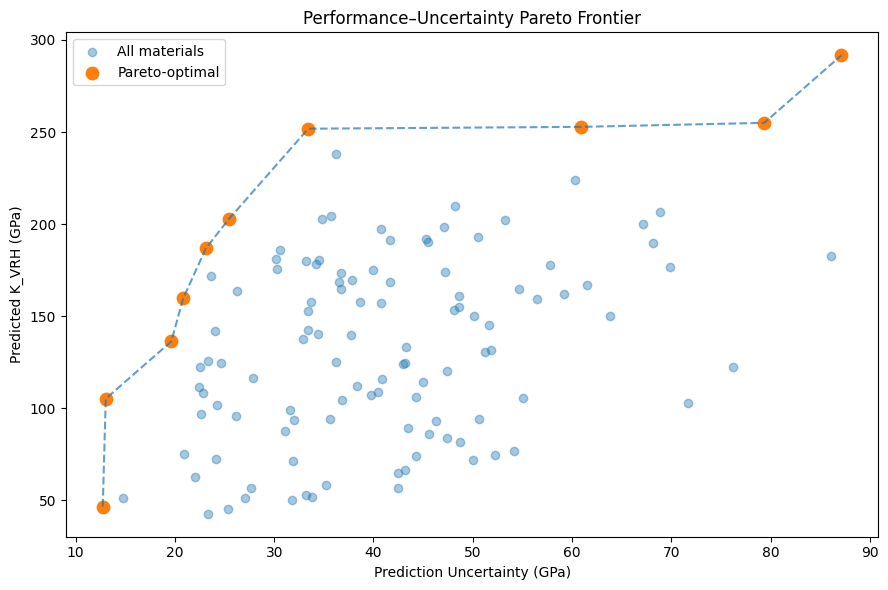

In [10]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6))

# All validation materials
plt.scatter(
    selection_df["uncertainty"],
    selection_df["predicted_K_VRH"],
    alpha=0.4,
    label="All materials"
)

# Pareto-optimal materials
plt.scatter(
    pareto_candidates["uncertainty"],
    pareto_candidates["predicted_K_VRH"],
    s=80,
    label="Pareto-optimal"
)

# Connect Pareto frontier
pareto_plot = pareto_candidates.sort_values(
    "uncertainty"
)

plt.plot(
    pareto_plot["uncertainty"],
    pareto_plot["predicted_K_VRH"],
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Prediction Uncertainty (GPa)")
plt.ylabel("Predicted K_VRH (GPa)")
plt.title("Performance–Uncertainty Pareto Frontier")

plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "pareto_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
pareto_profiles = pareto_candidates.copy()

# Higher predicted performance -> better
pareto_profiles["performance_norm"] = (
    pareto_profiles["predicted_K_VRH"]
    - pareto_profiles["predicted_K_VRH"].min()
) / (
    pareto_profiles["predicted_K_VRH"].max()
    - pareto_profiles["predicted_K_VRH"].min()
)

# Lower uncertainty -> better
pareto_profiles["reliability_norm"] = 1 - (
    (
        pareto_profiles["uncertainty"]
        - pareto_profiles["uncertainty"].min()
    )
    / (
        pareto_profiles["uncertainty"].max()
        - pareto_profiles["uncertainty"].min()
    )
)

In [12]:
pareto_profiles["balanced_score"] = (
    0.5 * pareto_profiles["performance_norm"]
    + 0.5 * pareto_profiles["reliability_norm"]
)

In [13]:
high_performance = pareto_profiles.loc[
    pareto_profiles["predicted_K_VRH"].idxmax()
]

low_risk = pareto_profiles.loc[
    pareto_profiles["uncertainty"].idxmin()
]

balanced = pareto_profiles.loc[
    pareto_profiles["balanced_score"].idxmax()
]

In [14]:
profile_selection = pd.DataFrame([
    {
        "Profile": "High Performance",
        "Material ID": high_performance["material_id"],
        "Formula": high_performance["formula"],
        "Predicted K_VRH": high_performance["predicted_K_VRH"],
        "Uncertainty": high_performance["uncertainty"],
        "Balanced Score": high_performance["balanced_score"]
    },
    {
        "Profile": "Balanced",
        "Material ID": balanced["material_id"],
        "Formula": balanced["formula"],
        "Predicted K_VRH": balanced["predicted_K_VRH"],
        "Uncertainty": balanced["uncertainty"],
        "Balanced Score": balanced["balanced_score"]
    },
    {
        "Profile": "Low Risk",
        "Material ID": low_risk["material_id"],
        "Formula": low_risk["formula"],
        "Predicted K_VRH": low_risk["predicted_K_VRH"],
        "Uncertainty": low_risk["uncertainty"],
        "Balanced Score": low_risk["balanced_score"]
    }
])

profile_selection.round(3)

,Profile,Material ID,Formula,Predicted K_VRH,Uncertainty,Balanced Score
0,High Performance,mp-1894,WC,291.673,87.124,0.50
1,Balanced,mp-1082,VIr3,251.803,33.428,0.78
2,Low Risk,mp-2624,AlSb,46.654,12.733,0.50


In [15]:
def add_validation_information(
    profile_selection,
    pareto_profiles
):
    validation_lookup = (
        pareto_profiles
        .set_index("material_id")
    )

    result = profile_selection.copy()

    result["Actual K_VRH"] = (
        result["Material ID"]
        .map(validation_lookup["actual_K_VRH"])
    )

    result["Absolute Error"] = np.abs(
        result["Actual K_VRH"]
        - result["Predicted K_VRH"]
    )

    return result


profile_validation = add_validation_information(
    profile_selection,
    pareto_profiles
)

profile_validation.round(2)

,Profile,Material ID,Formula,Predicted K_VRH,Uncertainty,Balanced Score,Actual K_VRH,Absolute Error
0,High Performance,mp-1894,WC,291.67,87.12,0.50,385.19,93.52
1,Balanced,mp-1082,VIr3,251.80,33.43,0.78,319.66,67.86
2,Low Risk,mp-2624,AlSb,46.65,12.73,0.50,49.20,2.55


## Phase 7 Summary — Uncertainty-Aware Material Selection

An uncertainty-aware material selection framework was developed using two
competing objectives:

1. Higher predicted bulk modulus (`K_VRH`)
2. Lower predictive uncertainty

### Pareto-Based Selection

Rather than immediately combining performance and uncertainty into an
arbitrary single score, Pareto optimization was first used to identify
non-dominated materials.

A material was considered Pareto-optimal when no other candidate provided
both:

- equal or higher predicted `K_VRH`, and
- equal or lower predictive uncertainty,

with at least one strict improvement.

Among 118 validation materials, 10 were identified as Pareto-optimal.

### Decision Profiles

Three decision profiles were defined:

- **High Performance:** maximizes predicted `K_VRH`
- **Low Risk:** minimizes predictive uncertainty
- **Balanced:** gives equal normalized importance to predicted performance
  and reliability

The balanced score was defined only after restricting the candidate set to
the Pareto frontier. The 50/50 weighting represents a decision scenario,
not a universally optimal weighting.

The selected materials were:

- High Performance: WC (`mp-1894`)
- Balanced: VIr3 (`mp-1082`)
- Low Risk: AlSb (`mp-2624`)

### Post-Selection Validation

The true validation targets were not used during candidate selection.
They were examined only after the selections had been made.

For the three selected examples:

- WC: uncertainty = 87.12 GPa, absolute error = 93.52 GPa
- VIr3: uncertainty = 33.43 GPa, absolute error = 67.86 GPa
- AlSb: uncertainty = 12.73 GPa, absolute error = 2.55 GPa

These three examples should not be interpreted as statistical evidence by
themselves. The broader validation evidence for the usefulness of uncertainty
comes from the correlation, uncertainty-group, and risk-coverage analyses
performed in Phase 6.

### Conclusion

The framework extends conventional property prediction into a decision-support
system that explicitly exposes the trade-off between predicted material
performance and prediction risk.

The test set remains untouched and will be used only for final evaluation.